# Transformers desde (casi) cero

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion3/1-transformers-from-scratch.ipynb)

En este notebook implementaremos un clasificador de sentimientos en ingles utilizando transformers. Implementaremos parte de la arquitectura del modelo pieza por pieza para ver como funciona por dentro. Sin embargo, utilizarémos las utilidades de tokenización de huggingface transformers para ayudarnos con esta tarea.

#### Referencias
- Dataset: sentimentdataset.csv

In [1]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

working_set = pkg_resources.working_set
installed_packages = [package.key for package in (working_set if working_set is not None else [])]
IN_COLAB = 'google-colab' in installed_packages

C:\Users\apapa\AppData\Local\Temp\ipykernel_60184\1224929533.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


### Cargando el dataset
Este es un dataset pequeño de expresiones de sentimientos y su evaluacion.

In [2]:
import pandas as pd
import warnings
import os
import re
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Resuelve la ruta del CSV relativa al notebook, independientemente del cwd del kernel.
_nb_file = globals().get('__vsc_ipynb_file__', None)
_nb_dir = os.path.dirname(os.path.abspath(_nb_file)) if _nb_file else os.getcwd()
dataset_file = os.path.join(_nb_dir, 'sentimentdataset.csv')

print("[Inicio] Preparando carga y limpieza del dataset...")
print(f"[Info] Buscando dataset en: {dataset_file}")

if not os.path.exists(dataset_file):
    print(f"[Error] No se encontró el archivo '{dataset_file}'.")
    df_raw = pd.DataFrame(columns=['Text', 'Sentiment'])
    dataset = []
else:
    print(f"[1/5] Cargando dataset...")
    df_raw = pd.read_csv(dataset_file)
    df_raw = df_raw[['Text', 'Sentiment']].copy()
    print(f"Registros iniciales: {len(df_raw)}")

    df_raw['Text'] = df_raw['Text'].fillna('').astype(str).str.strip()
    df_raw['Sentiment'] = df_raw['Sentiment'].fillna('').astype(str).str.strip()
    print("[2/5] Limpieza básica aplicada en columnas Text y Sentiment.")

    def normalize_sentiment_label(label: str) -> str:
        label = str(label).strip().lower()
        label = re.sub(r"[^a-z\s\-]", "", label)
        label = label.replace('-', ' ')
        label = re.sub(r"\s+", " ", label).strip()

        alias_map = {
            'joy': {'joy', 'happy', 'happiness', 'elation', 'euphoria', 'enthusiasm', 'amusement', 'overjoyed', 'playfuljoy', 'festivejoy', 'zest', 'celebration', 'contentment', 'serenity', 'positivity'},
            'sadness': {'sad', 'sadness', 'grief', 'despair', 'melancholy', 'heartbreak', 'sorrow', 'loss', 'loneliness', 'disappointment', 'devastated', 'desolation', 'heartache', 'ruins', 'darkness', 'exhaustion', 'lostlove', 'solitude'},
            'anger': {'anger', 'hate', 'frustration', 'frustrated', 'bitterness', 'bitter', 'resentment', 'betrayal', 'disgust', 'regret'},
            'fear': {'fear', 'fearful', 'anxiety', 'apprehensive', 'intimidation', 'helplessness', 'pressure', 'suffering', 'emotionalstorm'},
            'love': {'love', 'affection', 'adoration', 'gratitude', 'grateful', 'appreciation', 'compassion', 'compassionate', 'empathetic', 'kindness', 'friendship', 'romance', 'heartwarming', 'touched', 'connection'},
            'surprise': {'surprise', 'awe', 'amazement', 'wonder', 'wonderment', 'enchantment', 'captivation', 'marvel', 'thrill'}
        }

        for canonical_label, aliases in alias_map.items():
            if label in aliases:
                return canonical_label
        return label

    print("[3/5] Normalizando etiquetas de sentimiento...")
    df_raw['Sentiment_norm'] = df_raw['Sentiment'].apply(normalize_sentiment_label)
    df_raw = df_raw[(df_raw['Text'] != '') & (df_raw['Sentiment_norm'] != '')].copy()
    normalized_counts = df_raw['Sentiment_norm'].value_counts()
    print(f"Etiquetas normalizadas detectadas: {normalized_counts.shape[0]}")

    print("[4/5] Agrupando clases raras en 'other'...")
    min_samples_per_class = 10
    valid_classes = normalized_counts[normalized_counts >= min_samples_per_class].index
    df_raw['Sentiment'] = df_raw['Sentiment_norm'].where(
        df_raw['Sentiment_norm'].isin(valid_classes), 'other'
    )

    final_counts = df_raw['Sentiment'].value_counts()
    dataset = df_raw[['Text', 'Sentiment']].to_dict('records')

    print("[5/5] Dataset listo para modelado.")
    print(f"Total de registros finales: {len(dataset)}")
    print(f"Clases: {final_counts.shape[0]}")
    print(final_counts)

df_raw[['Text', 'Sentiment']].head()


[Inicio] Preparando carga y limpieza del dataset...
[Info] Buscando dataset en: c:\Users\apapa\GitHub\icesi-nlp\Entregables\Entregable\Sesion 3\sentimentdataset.csv
[1/5] Cargando dataset...
Registros iniciales: 732
[2/5] Limpieza básica aplicada en columnas Text y Sentiment.
[3/5] Normalizando etiquetas de sentimiento...
Etiquetas normalizadas detectadas: 121
[4/5] Agrupando clases raras en 'other'...
[5/5] Dataset listo para modelado.
Total de registros finales: 732
Clases: 12
Sentiment
other         269
joy           128
sadness        68
love           47
anger          46
positive       45
excitement     37
surprise       31
neutral        18
fear           16
curiosity      16
nostalgia      11
Name: count, dtype: int64


,Text,Sentiment
0,Enjoying a beautiful day at the park!,positive
1,Traffic was terrible this morning.,other
2,Just finished an amazing workout! 💪,positive
3,Excited about the upcoming weekend getaway!,positive
4,Trying out a new recipe for dinner tonight.,neutral


Observemos uno de sus registros...

In [3]:
dataset[0]

{'Text': 'Enjoying a beautiful day at the park!', 'Sentiment': 'positive'}

In [4]:
text_lengths = [len(record['Text']) for record in dataset]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

Texto más corto: 27
Texto más largo: 156
Longitud promedio: 84.42622950819673


Estos valores son la cantidad de *caractéres* que tiene las secuencias. Una decisión ingenua pero útil en este momento podría ser ajustar la longitud de las secuencias que vamos a usar para el entrenamiento a unos 2000 tokens. Esto podría ser suficiente para capturar una porción significativa de los textos.

## Definiendo el Tokenizer

Ahora, vamos a definir el tokenizer para nuestra tarea. Para ahorrarnos tiempo, vamos a entrenar uno basado en gpt2, pero ajustandolo a nuestro dataset. Para ello, debemos seleccionar una muestra representativa de nuestro dataset, como no es muy grande, casi que podemos usarlo todo. Luego, debemos definir el tamaño del vocabulario, es decir, cuantos tokens únicos queremos soportar en nuestro tokenizador. Para que un modelo de lenguaje funcione moderadamente bien para una tarea de clasificación, considerando el tamaño de nuestro corpus, deberíamos definir unos 50 mil tokens.

In [5]:
import os
from tqdm.auto import tqdm
from transformers import AutoTokenizer

# Usa el mismo directorio base que la celda de carga de datos.
_nb_file = globals().get('__vsc_ipynb_file__', None)
_nb_dir = os.path.dirname(os.path.abspath(_nb_file)) if _nb_file else os.getcwd()
TOKENIZER_SAVE_PATH = os.path.join(_nb_dir, "sentimental_tokenizer")

def bytes_to_unicode():
    bs = (
        list(range(ord("!"), ord("~") + 1))
        + list(range(ord("¡"), ord("¬") + 1))
        + list(range(ord("®"), ord("ÿ") + 1))
    )
    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8 + n)
            n += 1
    cs = [chr(n) for n in cs]
    return dict(zip(bs, cs))


if os.path.isdir(TOKENIZER_SAVE_PATH):
    print(f"[Tokenizer] Cargando tokenizador guardado desde '{TOKENIZER_SAVE_PATH}'...")
    sentimental_tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_SAVE_PATH)
    print("[Tokenizer] Tokenizador cargado correctamente.")
else:
    if not dataset:
        raise RuntimeError(
            "El dataset está vacío. Verifica que 'sentimentdataset.csv' exista y "
            "vuelve a ejecutar la celda de carga de datos."
        )

    length = min(10000, len(dataset))
    tokenizer = AutoTokenizer.from_pretrained("gpt2")

    byte_to_unicode_map = bytes_to_unicode()
    unicode_to_byte_map = dict((v, k) for k, v in byte_to_unicode_map.items())
    base_vocab = list(unicode_to_byte_map.keys())

    def batch_iterator(batch_size: int = 10):
        for start in tqdm(range(0, length, batch_size)):
            end = min(start + batch_size, length)
            batch = dataset[start:end]
            if batch:
                yield [record["Text"] for record in batch]

    print("[Tokenizer] Entrenando tokenizador...")
    sentimental_tokenizer = tokenizer.train_new_from_iterator(
        batch_iterator(), vocab_size=50000, initial_alphabet=base_vocab
    )
    sentimental_tokenizer.pad_token = sentimental_tokenizer.eos_token
    sentimental_tokenizer.save_pretrained(TOKENIZER_SAVE_PATH)
    print(f"[Tokenizer] Guardado en '{TOKENIZER_SAVE_PATH}'.")

if sentimental_tokenizer.pad_token is None:
    sentimental_tokenizer.pad_token = sentimental_tokenizer.eos_token

print(f"[Tokenizer] Listo. Vocab size: {sentimental_tokenizer.vocab_size} | pad_token: '{sentimental_tokenizer.pad_token}'")


[Tokenizer] Cargando tokenizador guardado desde 'c:\Users\apapa\GitHub\icesi-nlp\Entregables\Entregable\Sesion 3\sentimental_tokenizer'...
[Tokenizer] Tokenizador cargado correctamente.
[Tokenizer] Listo. Vocab size: 5921 | pad_token: '<|endoftext|>'


Exploremos ahora el tokenizador obtenido.

In [6]:
tokens = sorted(sentimental_tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {sentimental_tokenizer.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{sentimental_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{sentimental_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[1000:1015]])
print("Últimos 15 tokens:")
print([f"{sentimental_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Vocabulario: 5921 tokens
Primeros 15 tokens:
['<|endoftext|>', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.']
15 tokens de en medio:
['ious', 'joy', 'lm', 'mos', 'port', 'rant', 'rush', 'tem', 'ual', 'uil', 'ves', ' N', ' end', 'inter', ' tw']
Últimos 15 tokens:
[' metamorphosis', ' lightheartedness', ' refreshing', ' unburdened', ' Angkor', 'HeadphoneMystery', 'MovieNightStruggles', 'NeverTooLate', 'PeacefulAfternoon', 'RoadTrip', 'SelfieQueen', 'TVSeriesMarathon', 'TimelessMelodies', ' umbrella', ' bracelets']


In [7]:
sentimental_tokenizer("Challenging the world of people", max_length=8, truncation=True, padding='max_length').tokens()

['Ch', 'all', 'eng', 'ing', 'Ġthe', 'Ġworld', 'Ġof', 'Ġp']

In [8]:
import torch
import numpy as np
from typing import Dict
from torch.utils.data import Dataset


class SentimentalDataset(Dataset):

    def __init__(self, tokenizer, dataset, seq_length: int = 512):
        self.tokenizer = tokenizer
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.dataset = dataset
        self.seq_length = seq_length

        # dataset es una lista de dicts con claves 'Text' y 'Sentiment'
        categories = [r['Sentiment'] for r in dataset]
        texts = [r['Text'] for r in dataset]

        self.id_2_class_map = dict(enumerate(np.unique(categories)))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

        # Pre-tokenizamos todo una sola vez para eliminar el cuello de botella del DataLoader.
        encoded = self.tokenizer(texts, max_length=self.seq_length, truncation=True, padding='max_length')

        self.input_ids = torch.tensor(encoded['input_ids'], dtype=torch.long)
        self.attention_mask = torch.tensor(encoded['attention_mask'], dtype=torch.long)
        self.labels = torch.tensor([self.class_2_id_map[c] for c in categories], dtype=torch.long)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        return {
            'input_ids': self.input_ids[index],
            'attention_mask': self.attention_mask[index],
            'y': self.labels[index],
        }

    def __len__(self):
        return len(self.dataset)


Ahora instanciaremos el dataset entero. Para este experimento, definiremos un tamaño máximo de secuencia de 2048 **tokens**. Que según nuestra intuición arriba, debería ser suficiente para la tarea.

In [9]:
# Parametros originales del experimento.
max_len = 2048
Sentimental_dataset = SentimentalDataset(sentimental_tokenizer, dataset, seq_length=max_len)
assert len(Sentimental_dataset) == len(dataset)

Y luego, procedemos a hacer el train-val-test split y crear los dataloaders.

In [10]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import os

batch_size = 4 if not IN_COLAB else 12
# En notebooks de Windows evitamos multiproceso para prevenir PicklingError.
num_workers = 0 if os.name == 'nt' else 2
pin_memory = torch.cuda.is_available()

train_dataset, val_dataset, test_dataset = random_split(Sentimental_dataset, lengths=[0.8, 0.1, 0.1])

if num_workers > 0:
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=True,
        prefetch_factor=2,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=True,
        prefetch_factor=2,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=True,
        prefetch_factor=2,
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory,
    )

print(f"OS: {os.name} | batch_size: {batch_size} | workers: {num_workers} | pin_memory: {pin_memory}")

OS: nt | batch_size: 4 | workers: 0 | pin_memory: True


### Definición de los Positional Embeddings

In [11]:
import torch.nn as nn
from enum import Enum


class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):

    def __init__(self, max_len: int, d_model: int):
        super(SinusoidPE, self).__init__()

        # Definimos un vector columna con las posiciones de la secuencia de entrada (pos)
        pos = torch.arange(max_len).unsqueeze(1)
        # Definimos un vector de fila con las dimensiones del embedding (i)
        i = torch.arange(d_model).unsqueeze(0)

        # Calculamos el denominador segun la formula
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        # Aplicamos el denominador a las posiciones
        angle_rads = pos * div_term

        # Inicializamos la matriz de positional encodings
        pos_encoding = torch.zeros(max_len, d_model)
        # Calculamos los embeddings para los numeros pares con seno: PE(pos, 2i)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        # Calculamos los embdeddings para los numeros inpares con coseno: PE(pos, 2i+1)
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        # Registramos la variable como atributo de clase
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        pos_encoding = self._buffers["pos_encoding"]
        assert pos_encoding is not None
        return x + pos_encoding[:, :x.size(1), :]


class LearnablePE(nn.Module):

    def __init__(self, vocab_size: int, d_model: int, max_len: int = 0):
        super(LearnablePE, self).__init__()
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(0, max(x.size(-1), self.max_len))
        pos_emb = self.embedding(positions)
        return x + pos_emb


class TokenAndPosEmbedding(nn.Module):

    def __init__(self, max_len: int, embed_dim: int, vocab_size: int, pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID):
        super(TokenAndPosEmbedding, self).__init__()
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            self.pos_emb = LearnablePE(vocab_size, embed_dim)

    def forward(self, x):
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)

Ahora procedemos a instanciar el modulo que va a convertir los tokens en embeddings con positional embeddings.

In [12]:
emb_dim = 128 #if not IN_COLAB else 256
tpe = TokenAndPosEmbedding(max_len, emb_dim, sentimental_tokenizer.vocab_size)
if isinstance(tpe.pos_emb, SinusoidPE):
    pe = tpe.pos_emb._buffers.get("pos_encoding")
    if pe is None:
        raise ValueError("No se encontró 'pos_encoding' en el buffer de SinusoidPE.")
    pos_encoding = pe.squeeze(0).detach().cpu().numpy()
else:
    raise TypeError("tpe.pos_emb no es sinusoidal; no existe 'pos_encoding'.")


A manera exploratoria, podemos observar gráficamente en que consisten estos vectores. En el siguiente gráfico podemos observar como los valores tienden a oscilar para diferentes posiciones en la dimensionalidad del embedding. Los valores individuales no tienen una interpretación directa, pero lo que vale la pena resaltar es que se observa una "transición" a medida que nos desplazamos por las dimensiones del embedding y sus respectivas posiciones, no es solo ruido.

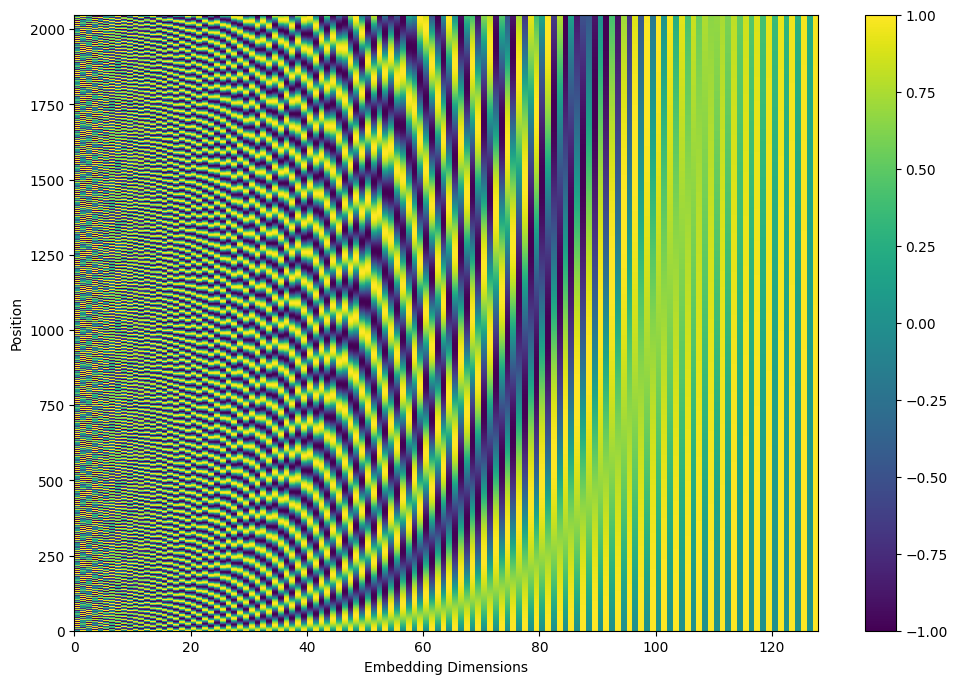

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.pcolormesh(pos_encoding, cmap='viridis')
plt.xlabel('Embedding Dimensions')
plt.xlim((0, emb_dim))
plt.ylabel('Position')
plt.colorbar()
plt.show()

Ahora, si pasamos nuestra frase simple por el tokenizador, deberíamos obtener una matriz con la forma: $(longitud, d_{model})$:

In [14]:
text = "Hello World!"
tokens = sentimental_tokenizer(text, max_length=max_len, truncation=True, padding='max_length')
x = torch.tensor(tokens['input_ids']).unsqueeze(0)
mask = torch.tensor(tokens['input_ids']).unsqueeze(0)
embedding = tpe(x)
embedding.shape

torch.Size([1, 2048, 128])

### Multi-Head Attention

In [15]:
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):

    def __init__(self, embed_size: int, num_heads: int = 8):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size % num_heads == 0, 'El tamaño del embedding debería ser divisible por el numero de cabezas'
        self.projection_dim = embed_size // num_heads
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        self.comibe_heads = nn.Linear(embed_size, embed_size)

    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None):
        # Camino optimizado: usa kernels acelerados (Flash/Memory-Efficient) cuando están disponibles.
        if mask is not None:
            bsz = mask.shape[0]
            attn_bias = torch.zeros((bsz, 1, 1, mask.shape[-1]), device=q.device, dtype=q.dtype)
            attn_bias = attn_bias.masked_fill(mask.reshape(bsz, 1, 1, -1) == 0, float('-inf'))
        else:
            attn_bias = None

        values = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_bias, dropout_p=0.0, is_causal=False)
        return values, None

    def _separate_heads(self, x, batch_size):
        # Llega: (batch, seq_len, emb_dim)
        x = x.reshape(batch_size, -1, self.num_heads, self.projection_dim)
        return x.permute(0, 2, 1, 3)

    def forward(self, x, mask=None, return_attention=False):
        # x: (batch, seq_len, emb_dim)
        batch_size, seq_len, emb_dim = x.size()
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = self._separate_heads(q, batch_size)
        k = self._separate_heads(k, batch_size)
        v = self._separate_heads(v, batch_size)

        weights, attention = self._scaled_dot_product(q, k, v, mask)
        weights = weights.permute(0, 2, 1, 3)
        weights = weights.reshape(batch_size, seq_len, emb_dim)
        output = self.comibe_heads(weights)

        if return_attention:
            return output, attention
        else:
            return output

Podemos hacer una prueba rápida de que las operaciones funcionan a nivel de matrices.

In [16]:
mha = MultiHeadAttention(emb_dim)
mha(embedding, mask).shape

torch.Size([1, 2048, 128])

### Definición del bloque transformers

![](../assets/transformers-achitecture.png)

Finalmente, definimos el bloque de transformers. Recordemos que como esta es una tarea de clasificación, solamente necesitamos el encoder, por lo que esto es silamente la primera parte del diseño de arquitecura de red.

En esta capa, simplemente ponemos una capa densa adicional junto con las normalizaciones a nivel de capa.

In [17]:
class TransformerBlock(nn.Module):

    def __init__(self, emb_dim: int, num_heads: int = 8):
        super(TransformerBlock, self).__init__()
        self.mhatt = MultiHeadAttention(emb_dim, num_heads)
        self.mhatt_dropput = nn.Dropout(0.2)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, emb_dim)
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)


    def forward(self, x, mask=None):
        attn_output = self.mhatt(x, mask)
        attn_output = self.mhatt_dropput(attn_output)
        attn_output = self.layer_norm1(attn_output)
        ffn_out = self.ffn(attn_output)
        return self.layer_norm2(ffn_out)


Nuevamente, probamos rapidamente para asegurarnos que las capas operan correctamente.

In [18]:
tb = TransformerBlock(emb_dim)
tb(embedding, mask).shape

torch.Size([1, 2048, 128])

In [19]:
num_heads = 8
vocab_size = sentimental_tokenizer.vocab_size

token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
transformer = TransformerBlock(emb_dim, num_heads)
ff = nn.Sequential(
    nn.Flatten(),
    nn.Linear(max_len * emb_dim, Sentimental_dataset.num_classes)
)

In [20]:
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
token_embeddings = token_embeddings.to(device)
transformer = transformer.to(device)

token_embeddings.eval()
transformer.eval()

# Evitamos dependencia del DataLoader para este benchmark puntual.
bench_bs = min(16, len(Sentimental_dataset))
x = Sentimental_dataset.input_ids[:bench_bs].to(device, non_blocking=True)
mask = Sentimental_dataset.attention_mask[:bench_bs].to(device, non_blocking=True)

# Warm-up para evitar medir costos de arranque.
with torch.inference_mode():
    for _ in range(5):
        _ = transformer(token_embeddings(x), mask)

if device.type == 'cuda':
    torch.cuda.synchronize()

# Benchmark real promedio.
runs = 20
start = time.perf_counter()
with torch.inference_mode():
    for _ in range(runs):
        embeddings = token_embeddings(x)
        attention = transformer(embeddings, mask)

if device.type == 'cuda':
    torch.cuda.synchronize()

elapsed = time.perf_counter() - start
ms_per_run = (elapsed / runs) * 1000

# Asignacion final con no_grad para obtener tensores normales (no inference tensors).
with torch.no_grad():
    embeddings = token_embeddings(x)
    attention = transformer(embeddings, mask)

assert embeddings.shape == (x.size(0), max_len, emb_dim)
assert attention.shape == (x.size(0), max_len, emb_dim)
print(f"Device: {device} | Avg embedding+attention: {ms_per_run:.2f} ms/run ({runs} runs)")
attention.shape

Device: cuda | Avg embedding+attention: 10.15 ms/run (20 runs)


torch.Size([16, 2048, 128])

In [21]:
# Prueba de la cabeza de clasificacion en modo evaluacion.
ff = ff.to(attention.device)
with torch.no_grad():
    pred = ff(attention)
pred.shape

torch.Size([16, 12])

### Definición del clasificador

Finalmente, definimos el modelo en si. Este modelo constará de 3 capas:

- La tokenización, tal como la definimos anteriormente.
- El transformer, que acabamos de decinir.
- Una capa densa adicional que servirá como clasificador de aquello que nos entregue la capa del transformer.

Como este es un LightningModule, aquí definiremos el resto de funciones utilitarias para el entrenamiento de la tarea.

In [22]:
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.callback import Callback
from torchmetrics import Accuracy

# Reducimos avisos informativos de CUDA/precision en notebook.
warnings.filterwarnings('ignore', message='.*Tensor Cores.*')

# Ajustes de rendimiento para GPU modernas.
torch.set_float32_matmul_precision("high")
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True


class SentimentalClassifier(LightningModule):

    def __init__(self, max_len: int, vocab_size: int, num_classes: int, emb_dim: int, num_heads: int = 8):
        super(SentimentalClassifier, self).__init__()
        self.num_classes = num_classes

        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
        self.transformer = TransformerBlock(emb_dim, num_heads)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
            nn.LogSoftmax(dim=1)
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)

    def forward(self, x, mask=None):
        embeddings = self.token_embeddings(x)
        attention = self.transformer(embeddings, mask)
        pooled = attention.mean(dim=1)
        return self.classifier(pooled)

    def training_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)

    def predict_step(self, batch):
        x, mask = batch['input_ids'], batch['attention_mask']
        return self(x, mask)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=2e-5, weight_decay=1e-5)
        return optimizer


model = SentimentalClassifier(
    max_len=Sentimental_dataset.seq_length,
    vocab_size=sentimental_tokenizer.vocab_size,
    num_classes=Sentimental_dataset.num_classes,
    emb_dim=emb_dim,
)

tb_logger = TensorBoardLogger('tb_logs', name='TransformersClassifier')
callbacks: list[Callback] = [EarlyStopping(monitor='train-loss', patience=3, mode='min')]

use_gpu = torch.cuda.is_available()
trainer = Trainer(
    max_epochs=10,
    accelerator='gpu' if use_gpu else 'cpu',
    devices=1,
    logger=tb_logger,
    callbacks=callbacks,
    precision='16-mixed' if use_gpu else 32,
    benchmark=True,
    enable_model_summary=False,
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


Observemos el proceso de entrenamiento

In [23]:
%load_ext tensorboard

In [29]:
import os
import socket
import subprocess
import sys
import time
from IPython.display import Markdown, IFrame, display

TB_LOGDIR = "tb_logs"
TB_PORT = 6007
TB_HOST = "127.0.0.1"


def _is_port_in_use(port: int, host: str = "127.0.0.1") -> bool:
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.settimeout(0.5)
        return sock.connect_ex((host, port)) == 0


# Levanta TensorBoard solo si aún no está corriendo en ese puerto.
if not _is_port_in_use(TB_PORT, TB_HOST):
    tb_cmd = [
        sys.executable,
        "-m",
        "tensorboard.main",
        "--logdir",
        TB_LOGDIR,
        "--port",
        str(TB_PORT),
        "--host",
        TB_HOST,
    ]
    tb_process = subprocess.Popen(tb_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(2)

url = f"http://{TB_HOST}:{TB_PORT}"
display(Markdown(f"### TensorBoard\nSi no ves el panel embebido, abre este enlace: [{url}]({url})"))
display(IFrame(src=url, width="100%", height="700"))

### TensorBoard
Si no ves el panel embebido, abre este enlace: [http://127.0.0.1:6007](http://127.0.0.1:6007)

Y como es de esperarse, realizaremos la validación contra el conjunto de prueba.

In [25]:
model.eval()
trainer.test(model, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test-acc          │    0.4931506812572479     │
└───────────────────────────┴───────────────────────────┘

[{'test-acc': 0.4931506812572479}]

### Haciendo predicciones

Finalmente, vamos a hacer uso del modelo y ver que tan bueno es para la clasificación de noticias.

In [26]:
from typing import List

pred_batches = trainer.predict(model, test_loader)
if pred_batches is None:
    raise RuntimeError('trainer.predict devolvio None.')

pred_tensors: List[torch.Tensor] = [p for p in pred_batches if isinstance(p, torch.Tensor)]
if len(pred_tensors) == 0:
    raise RuntimeError('trainer.predict no devolvio tensores de prediccion.')

predictions = torch.cat(pred_tensors, dim=0)
predictions = torch.argmax(predictions, dim=-1)
predictions = [Sentimental_dataset.id_2_class_map[int(pred)] for pred in predictions.cpu().numpy()]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [27]:
import pandas as pd

test_indices = list(test_dataset.indices)
subset = [dataset[i] for i in test_indices]

df = pd.DataFrame(
    data={
        "texto": [r['Text'] for r in subset],
        "tokens": [sentimental_tokenizer(r['Text'])['input_ids'] for r in subset],
        "categoría": [r['Sentiment'] for r in subset],
        'predicción': predictions,
    },
    index=pd.Index(test_indices, dtype='int64'),
)

df['tokens_string'] = df.tokens.apply(lambda t: sentimental_tokenizer.convert_ids_to_tokens(t))
df = df[["texto", "tokens", "tokens_string", "categoría", "predicción"]]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)


,texto,tokens,tokens_string,categoría,predicción
576,Engulfed in the aroma of freshly brewed coffee...,"[5798, 277, 263, 2337, 266, 2339, 4636, 1901, ...","[Engulfed, Ġin, Ġthe, Ġaroma, Ġof, Ġfreshly, Ġ...",other,other
493,"Amidst the tulip fields of Keukenhof, a tapest...","[2289, 263, 5579, 2650, 266, 5862, 12, 259, 15...","[Amidst, Ġthe, Ġtulip, Ġfields, Ġof, ĠKeukenho...",joy,other
391,Immersed in the enchanting melodies of a stree...,"[1856, 277, 263, 3195, 1815, 266, 259, 1575, 4...","[Immersed, Ġin, Ġthe, Ġenchanting, Ġmelodies, ...",other,other
22,Productive day ticking off my to-do list.,"[5458, 482, 5578, 2601, 398, 303, 13, 1951, 39...","[Productive, Ġday, Ġticking, Ġoff, Ġmy, Ġto, -...",positive,other
178,"Loneliness in a crowded room, a silent cry for...","[1210, 277, 259, 5139, 4594, 12, 259, 911, 262...","[Loneliness, Ġin, Ġa, Ġcrowded, Ġroom, ,, Ġa, ...",sadness,other
128,Empowerment through learning and personal growth.,"[2353, 385, 1267, 324, 714, 1828, 14]","[Empowerment, Ġthrough, Ġlearning, Ġand, Ġpers...",other,other
598,Rediscovered childhood cartoons and had a nost...,"[3228, 1871, 5321, 324, 4116, 259, 958, 13, 35...","[Rediscovered, Ġchildhood, Ġcartoons, Ġand, Ġh...",joy,joy
209,"Numb to the chaos, emotions locked away, a sto...","[2439, 303, 263, 1497, 12, 641, 2996, 1114, 12...","[Numb, Ġto, Ġthe, Ġchaos, ,, Ġemotions, Ġlocke...",other,other
26,Learning a new language for personal growth.,"[1608, 259, 423, 2719, 320, 714, 1828, 14]","[Learning, Ġa, Ġnew, Ġlanguage, Ġfor, Ġpersona...",positive,positive
624,"Started a community garden, growing not just p...","[1321, 259, 853, 566, 12, 4863, 703, 1503, 441...","[Started, Ġa, Ġcommunity, Ġgarden, ,, Ġgrowing...",joy,joy


In [28]:
errors = df[df['categoría'] != df['predicción']]
errors.head(15)

,texto,tokens,tokens_string,categoría,predicción
493,"Amidst the tulip fields of Keukenhof, a tapest...","[2289, 263, 5579, 2650, 266, 5862, 12, 259, 15...","[Amidst, Ġthe, Ġtulip, Ġfields, Ġof, ĠKeukenho...",joy,other
22,Productive day ticking off my to-do list.,"[5458, 482, 5578, 2601, 398, 303, 13, 1951, 39...","[Productive, Ġday, Ġticking, Ġoff, Ġmy, Ġto, -...",positive,other
178,"Loneliness in a crowded room, a silent cry for...","[1210, 277, 259, 5139, 4594, 12, 259, 911, 262...","[Loneliness, Ġin, Ġa, Ġcrowded, Ġroom, ,, Ġa, ...",sadness,other
137,The euphoria of a surprise birthday celebration.,"[536, 1702, 266, 259, 819, 1366, 1341, 14]","[The, Ġeuphoria, Ġof, Ġa, Ġsurprise, Ġbirthday...",joy,other
175,Disgust at the sight of injustice and cruelty.,"[3074, 391, 263, 3749, 266, 1894, 324, 4951, 14]","[Disgust, Ġat, Ġthe, Ġsight, Ġof, Ġinjustice, ...",anger,other
499,"At the summit of Machu Picchu, a breathtaking ...","[460, 263, 3130, 266, 4517, 5845, 12, 259, 159...","[At, Ġthe, Ġsummit, Ġof, ĠMachu, ĠPicchu, ,, Ġ...",surprise,other
551,"In the tennis tournament, a highly anticipated...","[386, 263, 3246, 1886, 12, 259, 4906, 4964, 29...","[In, Ġthe, Ġtennis, Ġtournament, ,, Ġa, Ġhighl...",anger,other
378,Embracing the thrill of speed on a rollercoast...,"[905, 263, 889, 266, 3093, 323, 259, 1595, 361...","[Embracing, Ġthe, Ġthrill, Ġof, Ġspeed, Ġon, Ġ...",surprise,other
655,Mastering the art of the perfect doodle during...,"[5517, 263, 512, 266, 263, 1325, 5687, 611, 39...","[Mastering, Ġthe, Ġart, Ġof, Ġthe, Ġperfect, Ġ...",joy,other
35,Quality time with family this weekend.,"[5532, 712, 319, 841, 1041, 1078, 14]","[Quality, Ġtime, Ġwith, Ġfamily, Ġthis, Ġweeke...",positive,other


## Conclusiones (comparado con Work 2)

Si comparo este trabajo con Work 2, la diferencia más grande no es solo el modelo, sino la forma de pensar el problema.

En **Work 2** trabajé con un enfoque más clásico (LSTM + baseline TF-IDF), que fue muy útil para tener resultados claros y métricas fáciles de interpretar. En **Work 3** me moví a una arquitectura tipo **Transformer**, que es más potente para capturar contexto, pero también más exigente en implementación, cómputo y depuración.

En términos simples: Work 2 se sintió más "estable" para evaluar rendimiento; Work 3 se sintió más "retador", pero también más cercano a lo que hoy se usa en NLP moderno.

Algo importante que me dejó esta comparación es que no siempre el modelo más complejo gana automáticamente. En Work 2 la evaluación quedó muy completa (accuracy, macro-F1, análisis por clase y errores), mientras que en Work 3 todavía falta cerrar esa parte con el mismo nivel de detalle para poder decir con total justicia cuál funciona mejor en este dataset.

También hubo un aprendizaje práctico fuerte: en notebooks reales, muchos errores no vienen de la teoría sino de detalles de ejecución (estado del kernel, padding del tokenizer, workers en Windows, orden de celdas). Resolver eso también es parte del trabajo de ciencia de datos.

Si tuviera que resumirlo en una idea:

- **Work 2** me dio una base sólida para medir.
- **Work 3** me dio una base sólida para escalar.

El siguiente paso natural es combinar lo mejor de ambos: mantener la evaluación rigurosa de Work 2 dentro del pipeline Transformer de Work 3. Ahí sí la comparación sería completa y mucho más útil para decidir qué modelo conviene usar en producción o en un contexto académico real.